# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [1]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [2]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [27]:
#Lectura prueba de dos día API
data_prueba_incio = datetime.datetime(2025, 7, 29)
data_prueba_fin = datetime.datetime(2025, 7, 30)
dias_total = (data_prueba_fin - data_prueba_incio).days + 1
fechas = []
for i in range(dias_total):
    fechas.append(data_prueba_incio + datetime.timedelta(days=i))

lista_dataframe = []

headers = {'x-ebirdapitoken': 'uhdb352ennvp'}
params = {'sppLocale':'es_CL'}
for fecha in fechas:
    api_url = f'https://api.ebird.org/v2/data/obs/CL/historic/{fecha.year}/{fecha.month}/{fecha.day}'
    try:
        resp = requests.get(api_url, headers=headers, params=params, timeout=5)
        resp.raise_for_status()
        data = resp.json()
        lista_dataframe.extend(data)
    except requests.exceptions.HTTPError as error:
        print(f'Error: {error} - Status_code: {resp.status_code}')

dframe = pd.DataFrame(lista_dataframe)
dframe.to_csv("pajaros_prueba.csv", encoding='utf-8', index=False)
dframe.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory
0,soulap1,Queltehue común,Vanellus chilensis,L50713726,"1331 Regidor Gustavo Binder, Osorno, Los Lagos...",2025-07-29 22:42,2.0,-40.597838,-73.101339,True,False,True,S263754431,NaN
1,brnowl,Lechuza,Tyto furcata,L50713726,"1331 Regidor Gustavo Binder, Osorno, Los Lagos...",2025-07-29 22:42,1.0,-40.597838,-73.101339,True,False,True,S263754431,NaN
2,rucspa1,Chincol,Zonotrichia capensis,L8304582,"Conjunto Los Ceibos, Viña del Mar",2025-07-29 21:47,1.0,-33.014282,-71.551717,True,False,True,S263701971,NaN
3,bcnher,Huairavo común,Nycticorax nycticorax,L50704827,"661 Cerro Tronador, Chiguayante, Bío Bío, CL (...",2025-07-29 18:35,3.0,-36.942293,-73.024711,True,False,True,S263715038,NaN
4,calqua,Codorniz,Callipepla californica,L30708017,Portezuelo conexión Renca-Quilicura,2025-07-29 18:30,1.0,-33.391795,-70.723345,True,False,False,S264010088,N


In [7]:
#Lectura de días 2022-2025 luego de prueba inicial
data_2022 = datetime.datetime(2022, 1, 1)
data_2025 = datetime.datetime(2025, 7, 31)
dias_total = (data_2025 - data_2022).days + 1
fechas = []
for i in range(dias_total):
    fechas.append(data_2022 + datetime.timedelta(days=i))

lista_dataframe = []

headers = {'x-ebirdapitoken': 'uhdb352ennvp'}
params = {'sppLocale':'es_CL'}
for fecha in fechas:
    api_url = f'https://api.ebird.org/v2/data/obs/CL/historic/{fecha.year}/{fecha.month}/{fecha.day}'
    try:
        resp = requests.get(api_url, headers=headers, params=params, timeout=35)
        resp.raise_for_status()
        data = resp.json()
        if data:
            lista_dataframe.extend(data)
    except requests.exceptions.HTTPError as error:
        print(f'Error: {error} - Status_code: {resp.status_code}')
    except requests.exceptions.RequestException as error:
        print(f'Error de conexión en {fecha.date()}: {error}')

df = pd.DataFrame(lista_dataframe)
df.to_csv("pajaros.csv", encoding='utf-8', index=False)    

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

In [112]:
data_pajaros = pd.read_csv('pajaros.csv', encoding='utf-8')

# Se leen las columnas y los datos nulos de cada una
data_pajaros.info()
print(
    '\nNotemos que la catgeoría "howMany" y "exoticCategory" tiene datos nulos,' \
    'sin embargo, en "exoticCategory" tiene sentido que hayan algunos datos nulos, ya que puede ser que la categoría no sea exótica.' \
    'Fíjemonos entonces en "obsValid" sea True.'
    'Nota: se decide no filtrar por ObsReviewed ya que al ser una categoría encargada a voluntarios reduce el dataset demasiado, y el\n' \
    'sistema de eBird ya tiene un filtro anterior a las Reviews https://support.ebird.org/en/support/solutions/articles/48000795278-the-ebird-review-process'
)

print(
    '\nA continuación la suma de datos nulos por columna hasta ahora:\n'
    )

data_pajaros.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272197 entries, 0 to 272196
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speciesCode      272197 non-null  object 
 1   comName          272197 non-null  object 
 2   sciName          272197 non-null  object 
 3   locId            272197 non-null  object 
 4   locName          272197 non-null  object 
 5   obsDt            272197 non-null  object 
 6   howMany          266893 non-null  float64
 7   lat              272197 non-null  float64
 8   lng              272197 non-null  float64
 9   obsValid         272197 non-null  bool   
 10  obsReviewed      272197 non-null  bool   
 11  locationPrivate  272197 non-null  bool   
 12  subId            272197 non-null  object 
 13  exoticCategory   6963 non-null    object 
dtypes: bool(3), float64(3), object(8)
memory usage: 23.6+ MB

Notemos que la catgeoría "howMany" y "exoticCategory" tiene datos nulos,si

speciesCode             0
comName                 0
sciName                 0
locId                   0
locName                 0
obsDt                   0
howMany              5304
lat                     0
lng                     0
obsValid                0
obsReviewed             0
locationPrivate         0
subId                   0
exoticCategory     265234
dtype: int64

In [114]:
data_filtrada = data_pajaros.copy()
data_filtrada = data_filtrada[data_filtrada['obsValid'] == True]
data_filtrada.info()

print(
    'Como todas las observaciones han sido validadas, filtraremos ahora los datos nulos en "howMany"\n' \
    'por la falta de información que provocan. Además borraremos los datos absurdos, es decir, cuando howMany sea negativo o 0.'
)

data_filtrada.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272197 entries, 0 to 272196
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speciesCode      272197 non-null  object 
 1   comName          272197 non-null  object 
 2   sciName          272197 non-null  object 
 3   locId            272197 non-null  object 
 4   locName          272197 non-null  object 
 5   obsDt            272197 non-null  object 
 6   howMany          266893 non-null  float64
 7   lat              272197 non-null  float64
 8   lng              272197 non-null  float64
 9   obsValid         272197 non-null  bool   
 10  obsReviewed      272197 non-null  bool   
 11  locationPrivate  272197 non-null  bool   
 12  subId            272197 non-null  object 
 13  exoticCategory   6963 non-null    object 
dtypes: bool(3), float64(3), object(8)
memory usage: 23.6+ MB
Como todas las observaciones han sido validadas, filtraremos ahora los dato

speciesCode             0
comName                 0
sciName                 0
locId                   0
locName                 0
obsDt                   0
howMany              5304
lat                     0
lng                     0
obsValid                0
obsReviewed             0
locationPrivate         0
subId                   0
exoticCategory     265234
dtype: int64

In [115]:
# Respuesta a)
data_filtrada = data_filtrada[data_filtrada['howMany'] > 0.0]

print('Y también borraremos los datos howMany fraccionarios, pues no tiene sentido un avistamiento de 1 ave y media.\n')
data_filtrada = data_filtrada[data_filtrada['howMany'] % 1 == 0]

data_filtrada.info()
total_avistamientos = len(data_filtrada)
print(f'\nCon nuestro DataFrame filtrado, se responde la pregunta a): El dataset tiene {int(total_avistamientos)} avistamientos.')

Y también borraremos los datos howMany fraccionarios, pues no tiene sentido un avistamiento de 1 ave y media.

<class 'pandas.core.frame.DataFrame'>
Index: 266893 entries, 0 to 272196
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speciesCode      266893 non-null  object 
 1   comName          266893 non-null  object 
 2   sciName          266893 non-null  object 
 3   locId            266893 non-null  object 
 4   locName          266893 non-null  object 
 5   obsDt            266893 non-null  object 
 6   howMany          266893 non-null  float64
 7   lat              266893 non-null  float64
 8   lng              266893 non-null  float64
 9   obsValid         266893 non-null  bool   
 10  obsReviewed      266893 non-null  bool   
 11  locationPrivate  266893 non-null  bool   
 12  subId            266893 non-null  object 
 13  exoticCategory   6798 non-null    object 
dtypes: bool(3), float64(3), ob

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

In [116]:
# A continuación, para la suma de aves, se utiliza el DataFrame ya filtrado
# Primero, guardaremos estos datos en un csv para responder las preguntas futuras
data_filtrada.to_csv('avistamientos_filtrados.csv', index=False, encoding='utf-8')

# Respuesta b)
avistamientos_aves_especie = data_filtrada['comName'].value_counts()
avistamientos_top_10 = avistamientos_aves_especie.head(10).sum()
porcentaje_top = (avistamientos_top_10 / total_avistamientos) * 100

print(
    f'Notamos que la cantidad de avistamientos en el top10 es de {avistamientos_top_10}, lo que es un {round(porcentaje_top, 2)}% aproximadamente del total de los'
    ' avistamientos'
    '\ncontados en total. Esto nos lleva a la conclusión de que hay una gran variedad de especies distintas de aves en el dataset. Además, \ntambién podemos' \
    ' concluir que las 10 especies del top son las especies más comunes, es decir, deben poder ser vistas en lugares\nurbanizados o de fácil acceso, y no esconderse' \
    ' facilmente de las personas, además de ser comunes durante una gran parte de la época\n' \
    'del año, lo que las lleva a ser las especies más vistas.'
)

print('\nTop 10:')
avistamientos_aves_especie.head(10)


Notamos que la cantidad de avistamientos en el top10 es de 12937, lo que es un 4.85% aproximadamente del total de los avistamientos
contados en total. Esto nos lleva a la conclusión de que hay una gran variedad de especies distintas de aves en el dataset. Además, 
también podemos concluir que las 10 especies del top son las especies más comunes, es decir, deben poder ser vistas en lugares
urbanizados o de fácil acceso, y no esconderse facilmente de las personas, además de ser comunes durante una gran parte de la época
del año, lo que las lleva a ser las especies más vistas.

Top 10:


comName
Cernícalo              1303
Peuco                  1296
Garza grande           1294
Traro                  1293
Churrete patagónico    1293
Aguilucho común        1293
Torcaza                1292
Pitío austral          1292
Huairavo común         1291
Cotorra                1290
Name: count, dtype: int64

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [117]:
# Respuesta
data_a = pd.read_csv('avistamientos_filtrados.csv', encoding='utf-8')
data_a['obsDt'] = pd.to_datetime(data_a['obsDt'], errors='coerce')
data_a = data_a.dropna(subset=['obsDt'])
data_a['month'] = data_a['obsDt'].dt.month.astype('int64')
data_a['year-month'] = data_a['obsDt'].dt.strftime('%Y-%m')
data_a['obsDt'] = data_a['obsDt'].dt.date
data_a.to_csv('datos_nuevas_columnas.csv', encoding='utf-8', index=False)
data_a.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN,1,2022-01
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [118]:
data_a['lat'] = pd.to_numeric(data_a['lat'], errors='coerce')
data_a['lng'] = pd.to_numeric(data_a['lng'], errors='coerce')

# Limitamos a los datos no absurdos según el sistema de coordenadas dado
data_b = data_a.dropna(subset=['lat', 'lng'])
data_b = data_b[
    (data_b['lat'].between(-90, 90)) & 
    (data_b['lng'].between(-180, 180))
]

geo_df = gpd.GeoDataFrame(
    data_b,
    geometry=gpd.points_from_xy(data_b.lng, data_b.lat),
    crs="EPSG:4326"
)

print('Verificamos que las coordenadas correspondan al CRS:')
geo_df.crs


Verificamos que las coordenadas correspondan al CRS:


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [119]:
print('Un vistazo al GeoDataFrame creado:')
geo_df.head()

Un vistazo al GeoDataFrame creado:


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month,geometry
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN,1,2022-01,POINT (-73.11316 -40.58584)
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,POINT (-70.94766 -53.21457)
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,POINT (-70.94766 -53.21457)
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,POINT (-70.94766 -53.21457)
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,POINT (-70.94766 -53.21457)


### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [120]:
regional = gpd.read_file('zip://Regiones.zip!Regional.shp')
print(f'Veamos que regional no viene con el mismo CRS {regional.crs}, así que lo transformamos y verificamos nuevamente:')
regional = regional.to_crs('EPSG:4326')
regional.crs

Veamos que regional no viene con el mismo CRS EPSG:3857, así que lo transformamos y verificamos nuevamente:


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

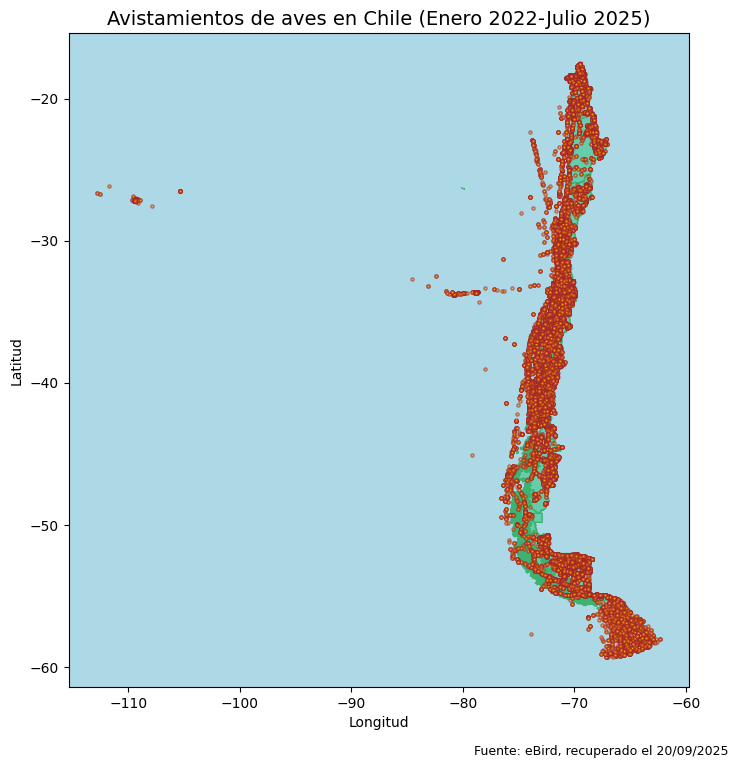

In [121]:
# Respuesta
fig, ax = plt.subplots(figsize=(8, 10))
regional.plot(ax=ax, color="mediumaquamarine", edgecolor="mediumseagreen")
geo_df.plot(ax=ax, color="orange", markersize=5, alpha=0.6, edgecolor="brown")
ax.set_facecolor('lightblue')

plt.title("Avistamientos de aves en Chile (Enero 2022-Julio 2025)", fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.figtext(0.95, 0.1,
           "Fuente: eBird, recuperado el 20/09/2025",
           wrap=True, horizontalalignment="right", fontsize=9)
plt.show()


_Al analizar el mapa de avistamientos, salta a la vista que la distribución de los registros tiene que ver con los patrones humanos. Por ejemplo, lo primero que podemos notar es la abrumadora concentración en la zona más central del país, un reflejo directo de la mayor densidad poblacional (https://www.geo-ref.net/sp/chl.htm). Lo cual tiene sentido, puesto que las observaciones las hacen humanos, y mientras más humanos, mayor probabilidad de que estos vean y documenten las aves._

_A pesar de que Chile es un país que sin lugar a dudas tiene varios pájaros y es difícil notar variaciones entre tantos datos, podemos notar que hacia las regiones de los extremos (continentales) los avistamientos no son en toda la zona, y que se tiene algunos "huecos"; en las regiones de Arica y Parinacota, Aysén y Magallanes, los avistamientos no están dispersos, sino que se agrupan en puntos más específicos. Tiene coincidencia con el punto anterior: tienen menos densidad poblacional. Pero, aparte de esto, podemos concluir que donde se concentran los avistamientos puede haber sitios turísticos, lugares naturales como humedales, en resumen, sitios de interés._

_Por otro lado, las costas de Chile mantienen una línea constante de registros, que flaquea hacia la región austral, lo que coincide con ser zonas de alta visitación turística y ecosistemas ricos para las aves (sin embargo, las costas de la zona austral son de difícil acceso y menos concurridas, siguiendo el oatrón ya antes mencionado). Alejándonos de la costa y adentrándonos en el mar, notamos la presencia de avistamientos en rutas específicas hacia el Pacífico, y además en una isla alejada del continente. Podemos concluir que estas rutas son, también, pesqueras o turísticas (línea recta en el mar). Pero un fenómeno interesante ocurre en medio del Pasaje de Drake, la excepción que confirma la regla: son registros hechos desde barcos, probablemente cruceros o expediciones científicas, debido a que es un lugar rico para amantes de la naturaleza._

_En resumen, el mapa no muestra necesariamente dónde están todas las aves, sino dónde los humanos las hemos buscado. eBird es una base de datos construida por y para humanos, así que notamos enseguida el sesgo: no sabremos si en los lugares más remotos hay más aves que en las ciudades basándonos únicamente en estos datos, ya que es lógico que a los lugares remotos irán menos personas y, en consecuencia, habrá menos avistamientos. Los tres factores clave que moldean este patrón son claros: la densidad de población, la facilidad de acceso y la existencia de rutas turísticas o científicas. Básicamente, es un mapa de nuestra propia huella como observadores._

_Aún así, no se le debe restar valor a este dataset: permite identificar patrones ecológicos relevantes, como la concentración de aves en costas, humedales y rutas marítimas, así como posibles zonas de interés turístico o científico. De esta forma, pese al sesgo, los datos siguen siendo útiles para detectar dinámicas espaciales y temporales de las especies._

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [122]:
data_frame = pd.read_csv('datos_nuevas_columnas.csv', encoding='utf-8')

print('Primero, nos aseguramos que cualquier error de tipeo entre también en las especies que buscamos. Para esto, normalizamos (con una nueva columna):')
data_frame['comName_norm'] = (
    data_frame['comName']
    .str.lower()
    .str.replace("-", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.strip()
)

data_frame.head()

Primero, nos aseguramos que cualquier error de tipeo entre también en las especies que buscamos. Para esto, normalizamos (con una nueva columna):


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month,comName_norm
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01,3.0,-40.585844,-73.113157,True,False,True,S99916680,NaN,1,2022-01,queltehuecomún
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01,4.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,bandurriacomún
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,tucúquere
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01,1.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,zorzalpatagónico
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01,2.0,-53.214573,-70.947665,True,False,True,S100024876,NaN,1,2022-01,chincol


In [123]:
# Run-run
run_run = data_frame[data_frame['comName_norm'] == 'runrun']
run_run = run_run.reset_index(drop=True)
#borramos la columna extra
run_run = run_run.drop(columns='comName_norm')
print('Dataframe de la especie Run-run:')
run_run.head()

Dataframe de la especie Run-run:


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
0,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-01,1.0,-29.899139,-71.270972,True,False,True,S99876937,NaN,1,2022-01
1,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-02,2.0,-29.899139,-71.270972,True,False,True,S99980322,NaN,1,2022-01
2,spetyr1,Run-run,Hymenops perspicillatus,L6511037,SN Humedal Angachilla--Puente Angachilla,2022-01-03,11.0,-39.866534,-73.238726,True,False,False,S100101766,NaN,1,2022-01
3,spetyr1,Run-run,Hymenops perspicillatus,L9860617,Llanquihue--Humedal Baquedano,2022-01-04,1.0,-41.250278,-73.008892,True,False,False,S100131688,NaN,1,2022-01
4,spetyr1,Run-run,Hymenops perspicillatus,L17401377,Isla Teja--Humedal Sur,2022-01-05,1.0,-39.820261,-73.258060,True,False,False,S100197285,NaN,1,2022-01


In [124]:
# Dormilona tontita
dormilona_tontita = data_frame[data_frame['comName_norm'] == 'dormilonatontita']
dormilona_tontita = dormilona_tontita.reset_index(drop=True)
#borramos la columna extra
dormilona_tontita = dormilona_tontita.drop(columns='comName_norm')
print('Dataframe de la especie Dormilona tontita:')
dormilona_tontita.head()

Dataframe de la especie Dormilona tontita:


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,month,year-month
0,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17444141,Base de Las Torres,2022-01-02,5.0,-50.914148,-72.966255,True,False,True,S100809770,NaN,1,2022-01
1,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L13297147,Río Alerce--Cascada Llanada Grande,2022-01-03,4.0,-41.871237,-71.920478,True,False,False,S100063840,NaN,1,2022-01
2,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1259323,PN Torres del Paine--Trek a mirador Torres del...,2022-01-04,2.0,-50.952222,-72.924585,True,False,False,S100992257,NaN,1,2022-01
3,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1030753,PN Torres del Paine--Lago Grey (sector sur),2022-01-05,2.0,-51.116510,-73.122983,True,False,False,S101584897,NaN,1,2022-01
4,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17443772,"Sendero Volcán Casablanca, Los Lagos, CL (-40....",2022-01-08,1.0,-40.771117,-72.171518,True,False,True,S100805036,NaN,1,2022-01


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

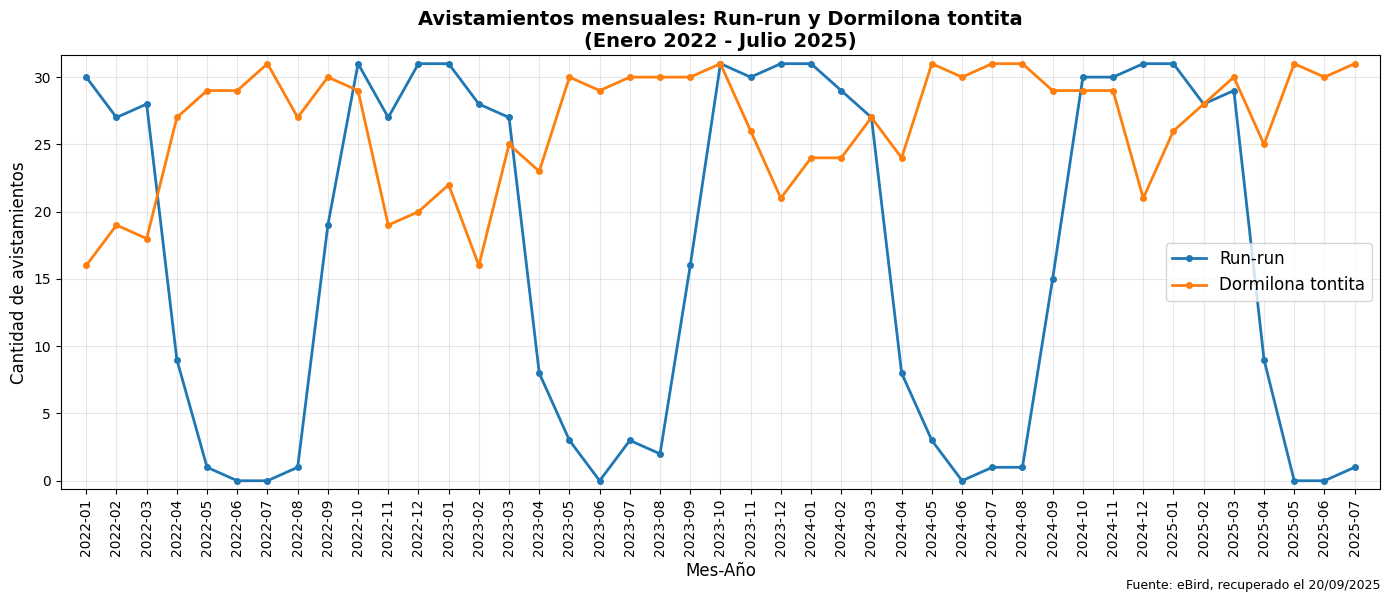

In [125]:
run_run_mesanio = run_run.groupby('year-month').size()
dormilona_tontita_mesanio = dormilona_tontita.groupby('year-month').size()
avistamientos = pd.date_range('2022-01', '2025-07', freq='MS').strftime('%Y-%m')

plt.figure(figsize=(14, 6))
plt.plot(avistamientos, run_run_mesanio.reindex(avistamientos, fill_value=0), 
         label='Run-run', marker='o', linewidth=2, markersize=4)
plt.plot(avistamientos, dormilona_tontita_mesanio.reindex(avistamientos, fill_value=0), 
         label='Dormilona tontita', marker='o', linewidth=2, markersize=4)
plt.xticks(avistamientos, rotation=90)
plt.xlabel('Mes-Año', fontsize=12)
plt.ylabel('Cantidad de avistamientos', fontsize=12)
plt.title('Avistamientos mensuales: Run-run y Dormilona tontita\n(Enero 2022 - Julio 2025)', 
          fontsize=14, fontweight='bold')
plt.figtext(0.99, 0.01,
           "Fuente: eBird, recuperado el 20/09/2025",
           wrap=True, horizontalalignment="right", fontsize=9)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.margins(x=0.02, y=0.02)
plt.tight_layout()
plt.show()



_Al analizar los avistamientos de la especie Run-run, se puede notar un patrón estacional muy marcado. La mayoría de los avistamientos ocurren entre los meses de abril-mayo y septiembre-octubre, coincidiendo con el otoño y la primavera en Chile. Durante los meses de invierno (junio-agosto) prácticamente desaparece, con registros casi nulos. Por el contrario, en los veranos (diciembre-febrero) las observaciones son significativamente menores, nunca alcanzan la misma intensidad que en los picos de otoño y primavera. En 2025, sin embargo, se observa una ausencia total en mayo, aunque el patrón general de los tres años anteriores se mantiene._

_Por otra parte, la Dormilona tontita presenta un patrón de avistamientos completamente diferente y menos estructurado. Se registran observaciones durante todo el año, manteniéndose de forma relativamente constante en torno a los 20-30 registros mensuales. No se aprecia un patrón estacional repetitivo._

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

In [126]:
import matplotlib.colors as mcolors
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

# Lectura mapa de Chile
regional = gpd.read_file('zip://Regiones.zip!Regional.shp')
regional = regional.to_crs('EPSG:4326')

# Transformamos ambos Dataframes a gpd

# Run-run
run_run['lat'] = pd.to_numeric(run_run['lat'], errors='coerce')
run_run['lng'] = pd.to_numeric(run_run['lng'], errors='coerce')
run_run = run_run.dropna(subset=['lat', 'lng'])
run_run = run_run[
    (run_run['lat'].between(-90, 90)) & 
    (run_run['lng'].between(-180, 180))
]
geo_rr = gpd.GeoDataFrame(
    run_run,
    geometry=gpd.points_from_xy(run_run.lng, run_run.lat),
    crs="EPSG:4326"
)

# Dormilona tontita
dormilona_tontita['lat'] = pd.to_numeric(dormilona_tontita['lat'], errors='coerce')
dormilona_tontita['lng'] = pd.to_numeric(dormilona_tontita['lng'], errors='coerce')
dormilona_tontita = dormilona_tontita.dropna(subset=['lat', 'lng'])
dormilona_tontita = dormilona_tontita[
    (dormilona_tontita['lat'].between(-90, 90)) & 
    (dormilona_tontita['lng'].between(-180, 180))
]
geo_dt = gpd.GeoDataFrame(
    dormilona_tontita,
    geometry=gpd.points_from_xy(dormilona_tontita.lng, dormilona_tontita.lat),
    crs="EPSG:4326"
)


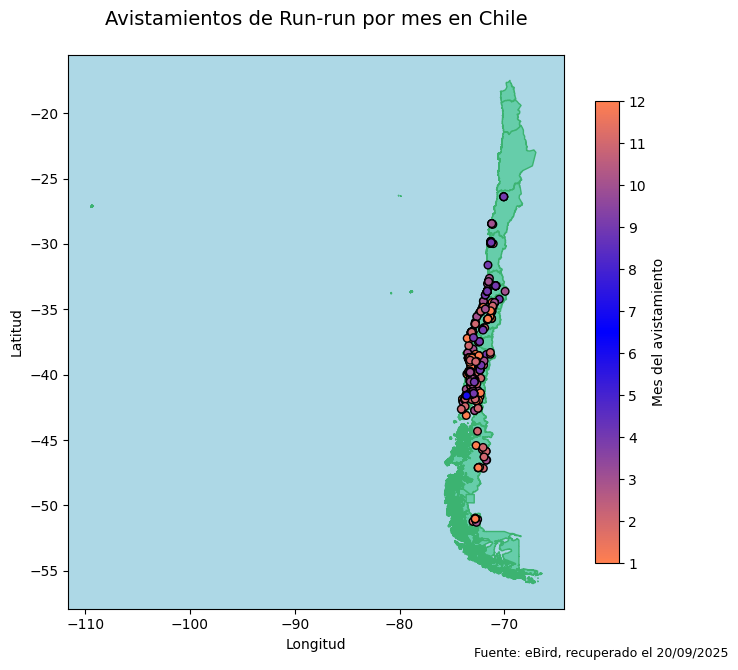

In [134]:
# Mapa Run-run

fig, ax = plt.subplots(figsize=(8, 10))
regional.plot(ax=ax, color="mediumaquamarine", edgecolor="mediumseagreen")

ax.set_facecolor('lightblue')
sc = ax.scatter(
    geo_rr['lng'], geo_rr['lat'], 
    c=geo_rr['month'], cmap=custom_cmap, s=30, edgecolor='k'
)
cbar = plt.colorbar(sc, ax=ax, ticks=np.arange(1,13), shrink=0.6, aspect=20)
cbar.set_label('Mes del avistamiento')
cbar.set_ticklabels(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'])
plt.title('Avistamientos de Run-run por mes en Chile\n', fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.figtext(0.95, 0.17,
           "Fuente: eBird, recuperado el 20/09/2025",
           wrap=True, horizontalalignment="right", fontsize=9)
plt.show()

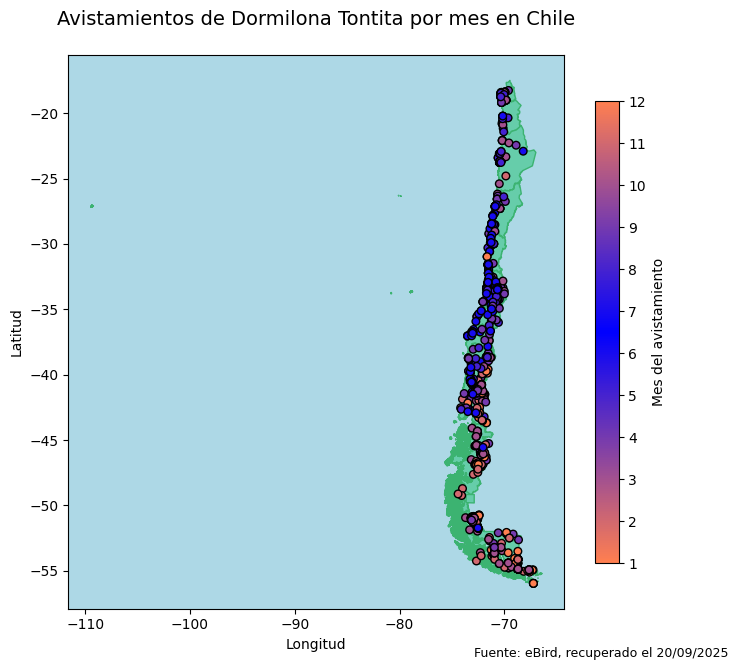

In [135]:
# Mapa Dormilona tontita

fig, ax = plt.subplots(figsize=(8, 10))
regional.plot(ax=ax, color="mediumaquamarine", edgecolor="mediumseagreen")

ax.set_facecolor('lightblue')
sc = ax.scatter(
    geo_dt['lng'], geo_dt['lat'], 
    c=geo_dt['month'], cmap=custom_cmap, s=30, edgecolor='k'
)
cbar = plt.colorbar(sc, ax=ax, ticks=np.arange(1,13), shrink=0.6, aspect=20)
cbar.set_label('Mes del avistamiento')
cbar.set_ticklabels(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12'])
plt.title('Avistamientos de Dormilona Tontita por mes en Chile\n', fontsize=14)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.figtext(0.95, 0.17,
           "Fuente: eBird, recuperado el 20/09/2025",
           wrap=True, horizontalalignment="right", fontsize=9)
plt.show()

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta

_La especie Run-run tiene una clara tendencia a estar en la zona centro-sur de Chile durante su estadía, sin embargo, notamos que cuando esta especie tiene avistamientos en la zona austral, son solo meses de clima cálido para el país, y tiran hacia la Cordillera, pero cuando se avistan (nuevamente, pocas veces comparando a la densidad de avistamientos en la zona centro-sur) hacia el norte, es en meses un poco más fríos (no invierno, sino primavera u otoño) y hacia la costa. En los meses de invierno, sin embargo, casi no se ven avistamientos, y si hay, es donde se concentra la mayor parte de avistamientos de la especie. De esto podemos concluir que esta especie arranca de climas extremos, probablemente prefiriendo zonas aclimatadas o con agua (costa, más hacia la cordillera), y que es una especie migratoria, que se va de Chile en los meses de invierno crudo._

_Por otro lado, la Dormilona tontita presenta un patrón completamente distinto. Como vimos antes, no tiene una estacionalidad marcada en la cantidad de avistamientos, y su distribución geográfica lo confirma: habita Chile de extremo a extremo durante todo el año. Sin embargo, sí muestra un patrón sutil: durante los meses fríos evita la zona austral, y durante los meses cálidos sí se le encuentra allí. Esto indica que, lejos de ser una migratoria estricta, es una especie con movimientos internos dentro de Chile, capaz de amoldarse sin abandonar el territorio nacional._

_En resumen, mientras el Run-run es un visitante migratorio estacionario del país, la Dormilona tontita es una residente adaptable que redistribuye su población a lo largo del país según la época del año._